In [1]:
import numpy as np
import pandas as pd
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [4]:
filename = 'https://raw.githubusercontent.com/yhilpisch/py4fi2nd/master/source/tr_eikon_eod_data.csv'

In [7]:
df = pd.read_csv(filename, index_col=0, parse_dates = True)

In [8]:
df.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4323,1096.35,NaN,NaN
2010-01-04,30.572827,30.950,20.88,133.90,173.08,113.33,1132.99,20.04,1.4411,1120.00,47.71,109.80
2010-01-05,30.625684,30.960,20.87,134.69,176.14,113.63,1136.52,19.35,1.4368,1118.65,48.17,109.70
2010-01-06,30.138541,30.770,20.80,132.25,174.26,113.71,1137.14,19.16,1.4412,1138.50,49.34,111.51
2010-01-07,30.082827,30.452,20.60,130.00,177.67,114.19,1141.69,19.06,1.4318,1131.90,49.10,110.82


<span style='font-size:17px'><b>Data Inspection: Eikon End-of-day Data</b>

* <b>Index:</b> The 'Date' column is parsed as a 'DateTimeIndex' to allow for time-based slicing and rolling operations.
* <b>Columns:</b> Each Column represents a financial instrument's closing price.
* <b>Initial Rows:</b> The first 5 rows provide a snapshot of the price levels and confirms the frequency of the data.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2138 non-null   float64
 1   MSFT.O  2138 non-null   float64
 2   INTC.O  2138 non-null   float64
 3   AMZN.O  2138 non-null   float64
 4   GS.N    2138 non-null   float64
 5   SPY     2138 non-null   float64
 6   .SPX    2138 non-null   float64
 7   .VIX    2138 non-null   float64
 8   EUR=    2216 non-null   float64
 9   XAU=    2211 non-null   float64
 10  GDX     2138 non-null   float64
 11  GLD     2138 non-null   float64
dtypes: float64(12)
memory usage: 225.1 KB


<span style='font-size:17px'><b>Data Structure & Integrity Check</b>

* <b>Index Type:</b> 'DattimeIndex' (2216 entries). This is crucial for time-series analysis, allowing for 'rolling' and resampling' operations.
* <b>Date Range:</b> Covers January 1,2010, through June 19, 2018.
* <b>Data Types:</b> All 12 columns are 'float64' (decimal numbers), which is the required format for calculating financial returns.
* <b>Memory Usage:</b> The dataset is lightweight at approximately 225.1 K, making it very fast to process in-memory.

In [11]:
df.tail()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2018-06-25,182.17,98.39,50.71,1663.15,221.54,271.00,2717.07,17.33,1.1702,1265.00,22.01,119.89
2018-06-26,184.43,99.08,49.67,1691.09,221.58,271.60,2723.06,15.92,1.1645,1258.64,21.95,119.26
2018-06-27,184.16,97.54,48.76,1660.51,220.18,269.35,2699.63,17.91,1.1552,1251.62,21.81,118.58
2018-06-28,185.50,98.63,49.25,1701.45,223.42,270.89,2716.31,16.85,1.1567,1247.88,21.93,118.22
2018-06-29,185.11,98.61,49.71,1699.80,220.57,271.28,2718.37,16.09,1.1683,1252.25,22.31,118.65


<span style='font-size:17px'><b>Tail Analysis</b>

* <b>Market Trends:</b> We can see Apple (AAPL.O) and Microsoft (MSFT.O) price levels around \$185 and \$98 respectively.
* <b>Volatility:</b> The '.VIX'(Fear Index) is hovering around 16-17, indicating moderate market sentiment.
* <b>Data Continuity:</b> The dates are sequential (25th through the 29th), confirming that the time series is intact at the end of the file.

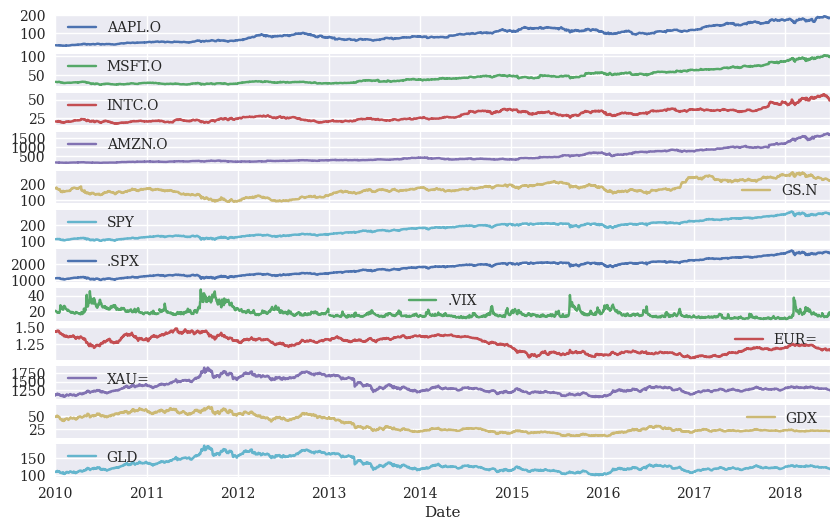

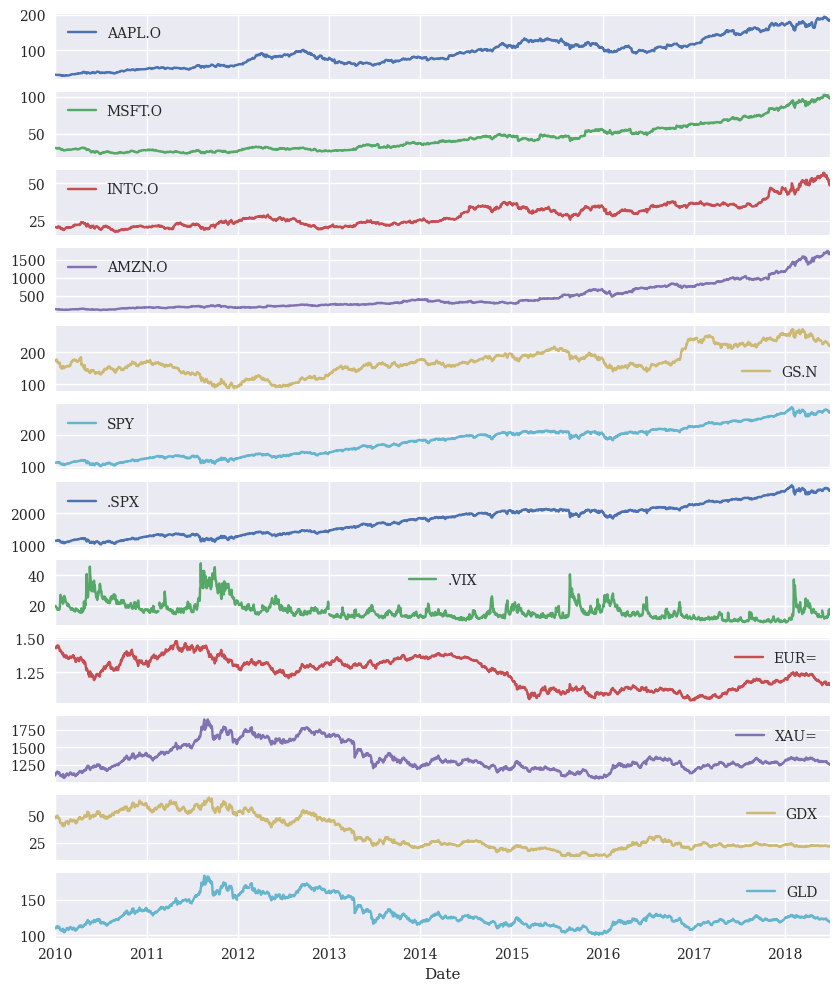

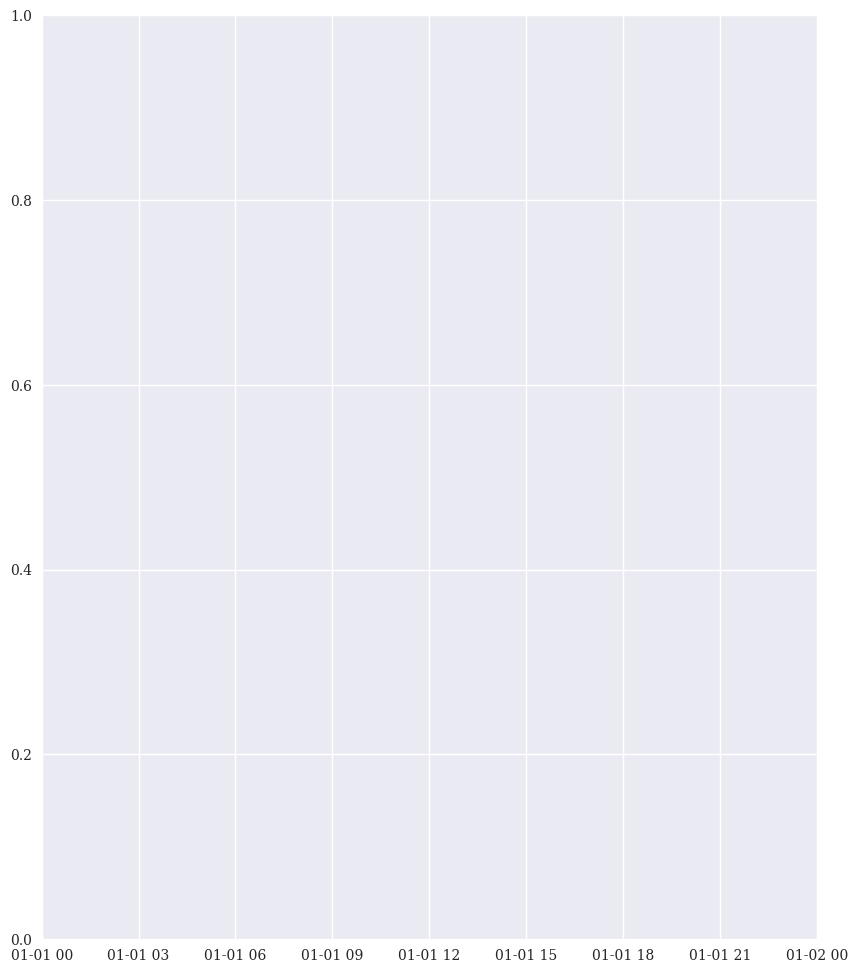

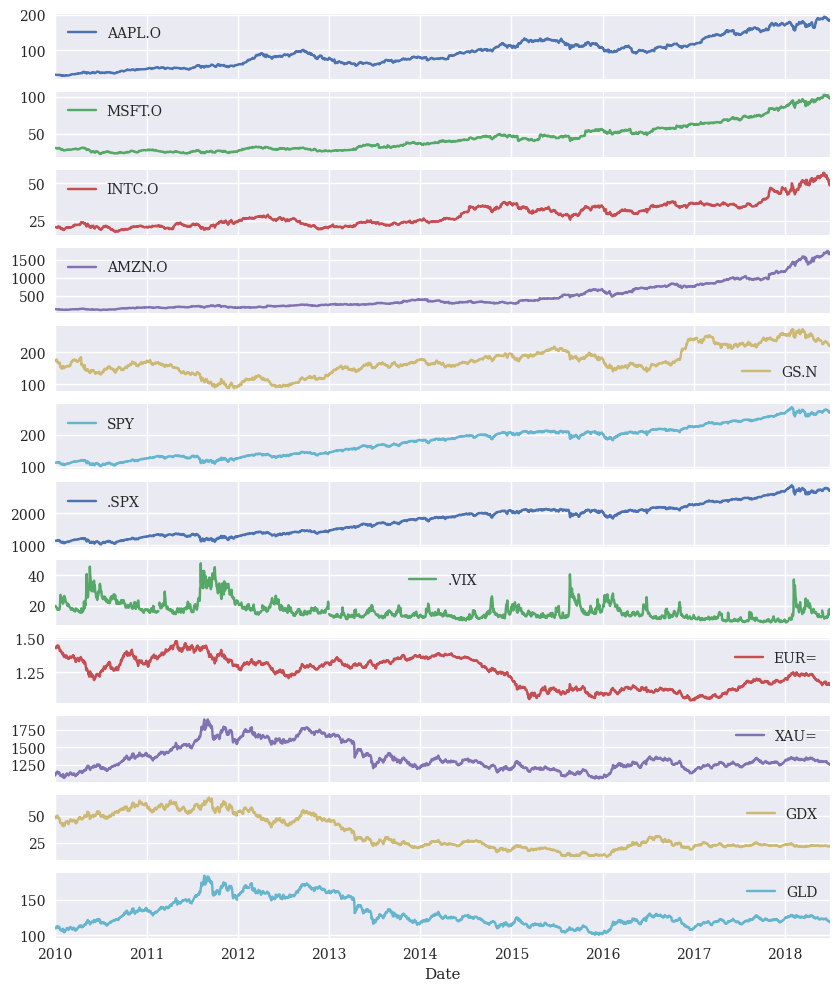

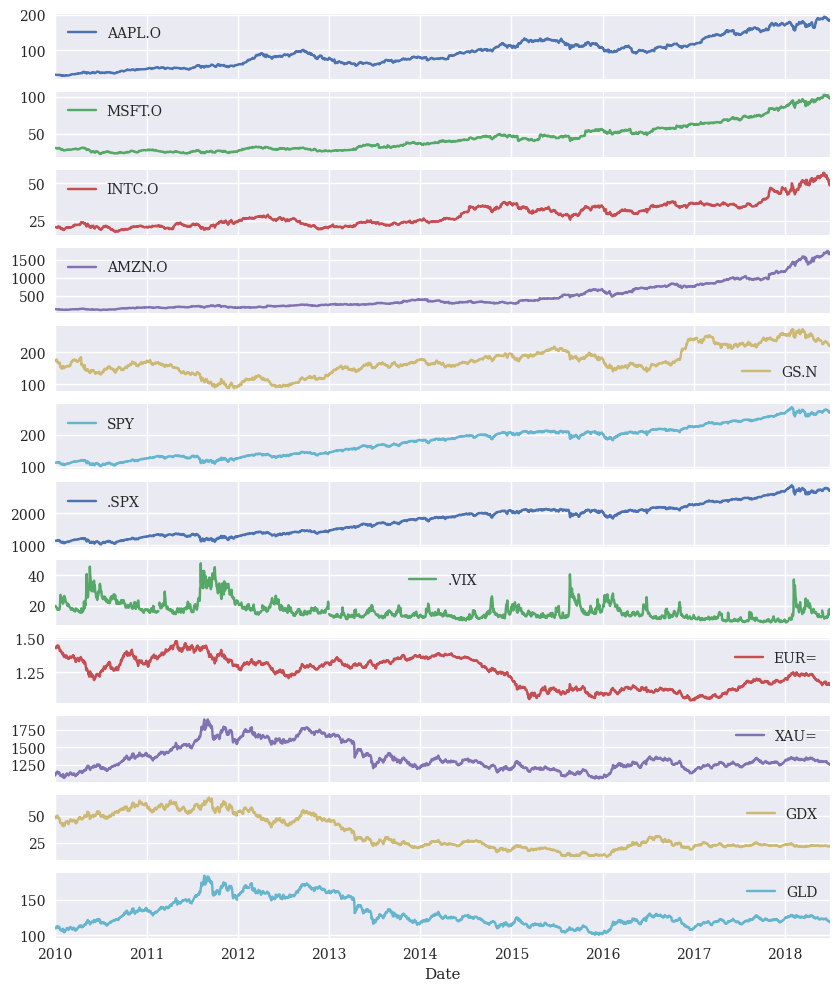

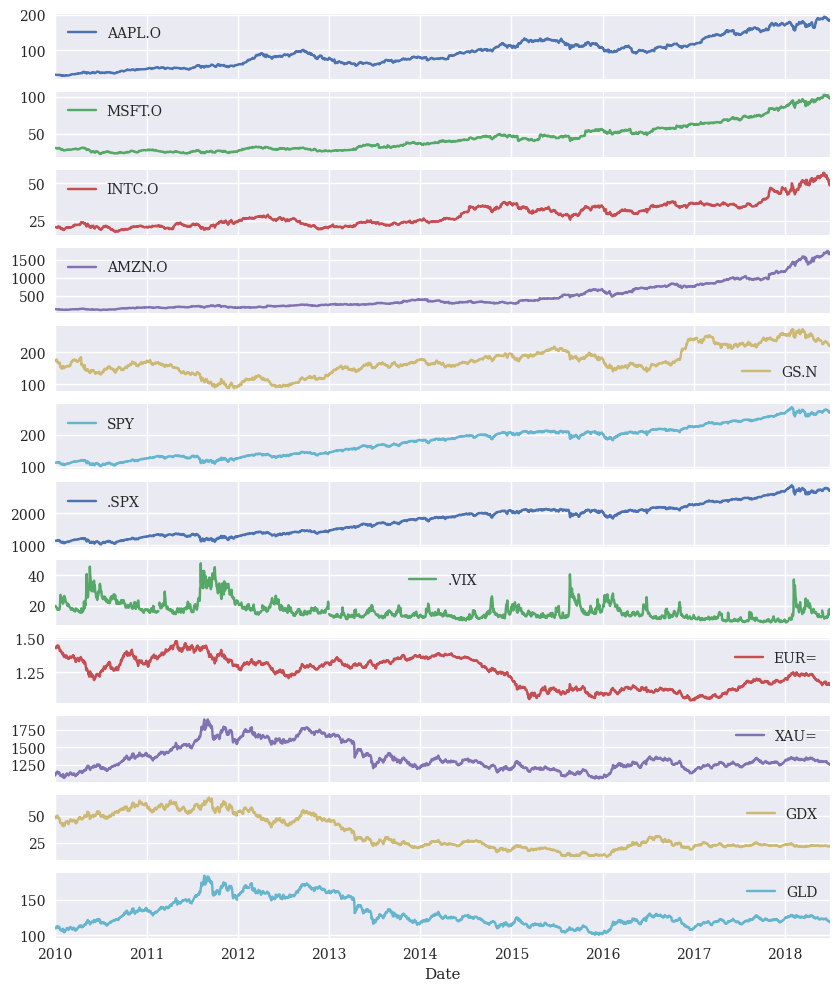

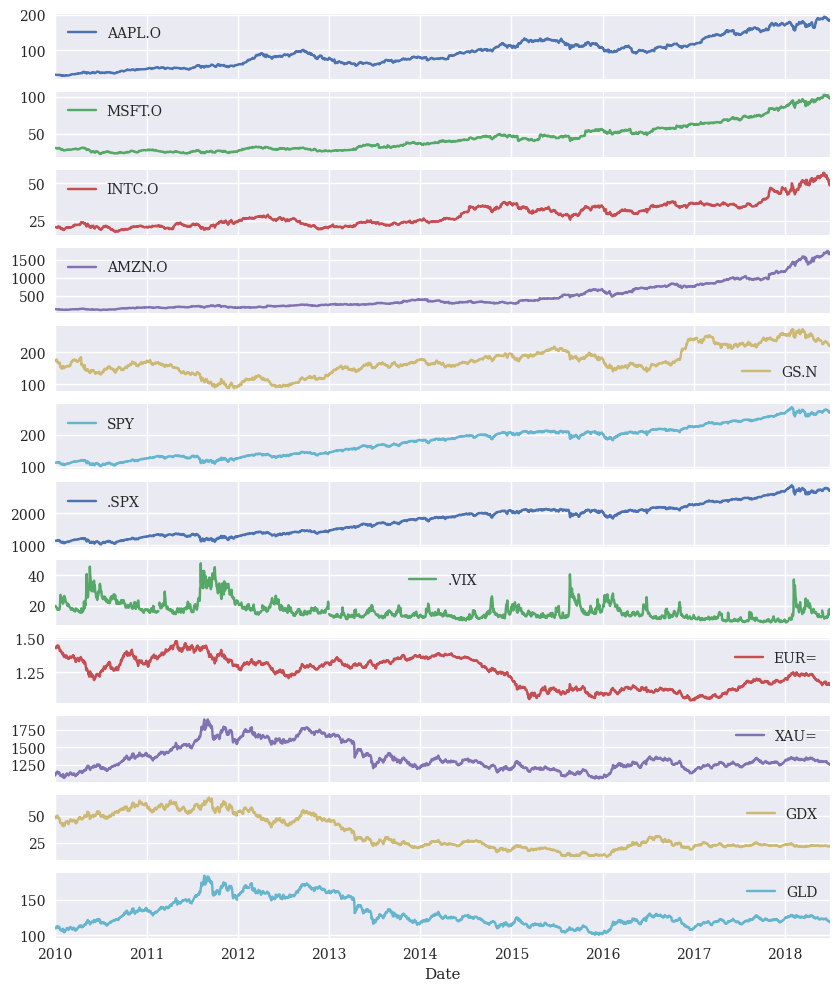

In [19]:
df.plot(figsize=(10,12), subplots=True);
plt.show()

<span style='font-size:17px'><b>Time Series Data Visualization</b>

* <b>Equities:</b> Technology stocks like AAPL.O, MSFT.O, and AMZN.O show long-term growth trends.
* <b>Indices:</b>The SPY and the .SPX provide a macro view of the broader market performance.
* <b>Volatility & FX:</b> The .VIX tracks market sentiment and 'fear', while EUR= monitors currency fluctuations.
  

In [20]:
instruments = ['Apple Stock', 'Microsoft Stock', 'Intel Stock', 'Amazon Stock', 'Goldman Sachs Stock','SPDR S&P 500 ETF Trust', 'S&P 500 index',
               'VIX Volatility Index', 'EUR/USD Exchange Rate', 'Gold Price', 'VanEck Vectors Gold Miners ETF', 'SPRD Gold Trust']

In [24]:
for ric, name in zip(df.columns, instruments):
    print ('{:8s}|{}'.format(ric,name))

AAPL.O  |Apple Stock
MSFT.O  |Microsoft Stock
INTC.O  |Intel Stock
AMZN.O  |Amazon Stock
GS.N    |Goldman Sachs Stock
SPY     |SPDR S&P 500 ETF Trust
.SPX    |S&P 500 index
.VIX    |VIX Volatility Index
EUR=    |EUR/USD Exchange Rate
XAU=    |Gold Price
GDX     |VanEck Vectors Gold Miners ETF
GLD     |SPRD Gold Trust


<span style='font-size:17px'><b>Insrument Mapping and RIC codes</b>

* The code block above maps the <b>Reuters Instrument Codes (RICs)</b> used in the 'DataFrame' columns to their full descriptive names.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2216 entries, 2010-01-01 to 2018-06-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  2138 non-null   float64
 1   MSFT.O  2138 non-null   float64
 2   INTC.O  2138 non-null   float64
 3   AMZN.O  2138 non-null   float64
 4   GS.N    2138 non-null   float64
 5   SPY     2138 non-null   float64
 6   .SPX    2138 non-null   float64
 7   .VIX    2138 non-null   float64
 8   EUR=    2216 non-null   float64
 9   XAU=    2211 non-null   float64
 10  GDX     2138 non-null   float64
 11  GLD     2138 non-null   float64
dtypes: float64(12)
memory usage: 225.1 KB


In [27]:
df.describe().round(2)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
count,2138.00,2138.00,2138.00,2138.00,2138.00,2138.00,2138.00,2138.00,2216.00,2211.00,2138.00,2138.00
mean,93.46,44.56,29.36,480.46,170.22,180.32,1802.71,17.03,1.25,1349.01,33.57,130.09
std,40.55,19.53,8.17,372.31,42.48,48.19,483.34,5.88,0.11,188.75,15.17,18.78
min,27.44,23.01,17.66,108.61,87.70,102.20,1022.58,9.14,1.04,1051.36,12.47,100.50
25%,60.29,28.57,22.51,213.60,146.61,133.99,1338.57,13.07,1.13,1221.53,22.14,117.40
50%,90.55,39.66,27.33,322.06,164.43,186.32,1863.08,15.58,1.27,1292.61,25.62,124.00
75%,117.24,54.37,34.71,698.85,192.13,210.99,2108.94,19.07,1.35,1428.24,48.34,139.00
max,193.98,102.49,57.08,1750.08,273.38,286.58,2872.87,48.00,1.48,1898.99,66.63,184.59


<span style='font-size:17px'><b>Summary Statistics and Asset Overview</b>

* <b>Scale Difference:</b> The 'mean' values highlight significant differences in nominal pricing-ranging from the EUR= exchange rate (1.25) to the S&P 500 Index (1802.71)
* <b>Volatility Insights:</b> The 'std' (standard deviation) and the spread between 'min' and 'max' reveal varying levels of risk.

In [29]:
df.mean()

AAPL.O      93.455973
MSFT.O      44.561115
INTC.O      29.364192
AMZN.O     480.461251
GS.N       170.216221
SPY        180.323029
.SPX      1802.713106
.VIX        17.027133
EUR=         1.248587
XAU=      1349.014130
GDX         33.566525
GLD        130.086590
dtype: float64

In [30]:
df.aggregate ([min,
               np.mean,
               np.std,
               np.median,
               max]
             ).round(2)
            

C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\3728852178.py:1: FutureWarning: The provided callable <built-in function min> is currently using Series.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  df.aggregate ([min,
C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\3728852178.py:1: FutureWarning: The provided callable <function mean at 0x000001BFBB667600> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.aggregate ([min,
C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\3728852178.py:1: FutureWarning: The provided callable <function std at 0x000001BFBB667740> is currently using Series.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df.aggregate ([min,
C:\Users\wyatt\AppData\Local\Temp\i

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
min,27.44,23.01,17.66,108.61,87.70,102.20,1022.58,9.14,1.04,1051.36,12.47,100.50
mean,93.46,44.56,29.36,480.46,170.22,180.32,1802.71,17.03,1.25,1349.01,33.57,130.09
std,40.55,19.53,8.17,372.31,42.48,48.19,483.34,5.88,0.11,188.75,15.17,18.78
median,90.55,39.66,27.33,322.06,164.43,186.32,1863.08,15.58,1.27,1292.61,25.62,124.00
max,193.98,102.49,57.08,1750.08,273.38,286.58,2872.87,48.00,1.48,1898.99,66.63,184.59


<span style='font-size:17px'><b>Custom Statistical Aggregation</b>

* After examining the standard descriptive statistics, we use the '.aggregate()' method to create a focused summary of specific metrics across the entire dataset.


In [31]:
df.diff().head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0088,23.65,NaN,NaN
2010-01-05,0.052857,0.010,-0.01,0.79,3.06,0.30,3.53,-0.69,-0.0043,-1.35,0.46,-0.10
2010-01-06,-0.487142,-0.190,-0.07,-2.44,-1.88,0.08,0.62,-0.19,0.0044,19.85,1.17,1.81
2010-01-07,-0.055714,-0.318,-0.20,-2.25,3.41,0.48,4.55,-0.10,-0.0094,-6.60,-0.24,-0.69


In [32]:
df.diff().mean()

AAPL.O    0.064737
MSFT.O    0.031246
INTC.O    0.013540
AMZN.O    0.706608
GS.N      0.028224
SPY       0.072103
.SPX      0.732659
.VIX     -0.019583
EUR=     -0.000119
XAU=      0.041887
GDX      -0.015071
GLD      -0.003455
dtype: float64

<span style='font-size:17px'><b>Transition to First-Difference Analysis</b>

* <b>Absolute Changes ('df.diff()'):</b> The first output shows the period-to-period change ($P_t - P_{t-1}$). The first row results in 'NaN' because there is no prior day to subtract from the start of the dataset.
* <b>Mean Daily Delta:</b>The second output provides the average daily absolute change for each asset. 


In [34]:
df.pct_change().round(3).head()

C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\1467224594.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.pct_change().round(3).head()


,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006,0.022,NaN,NaN
2010-01-05,0.002,0.000,-0.000,0.006,0.018,0.003,0.003,-0.034,-0.003,-0.001,0.010,-0.001
2010-01-06,-0.016,-0.006,-0.003,-0.018,-0.011,0.001,0.001,-0.010,0.003,0.018,0.024,0.016
2010-01-07,-0.002,-0.010,-0.010,-0.017,0.020,0.004,0.004,-0.005,-0.007,-0.006,-0.005,-0.006


<span style='font-size:17px'><b>Percentage Change ('df.pct_change()')</b>

* This calculates the daily return, representing the negative gain or loss for each asset. It is a critical step for modern portfolio theory and risk assessment.


C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\500465362.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.pct_change().mean().plot(kind='bar', figsize=(10,6))


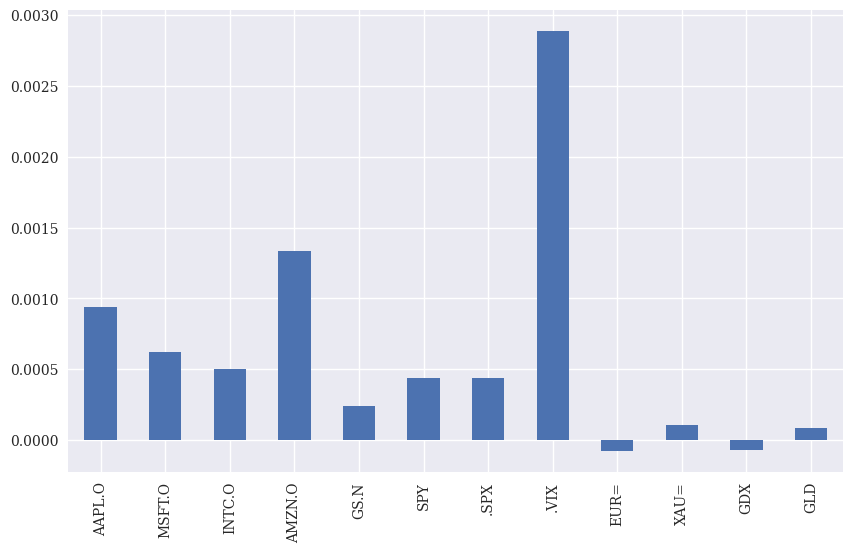

In [36]:
df.pct_change().mean().plot(kind='bar', figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Visualizing Average Daily Returns</b>

* <b>Outliers in Return:</b> The .VIX shows the highest daily average change, which is expected given its nature as a volatility index rather than a standard price-tracked equity.
* <b>Equity Performance:</b> Among individual stocks, AMZN.O and AAPL.O exhibit stronger average daily growth compared to the broader indices like SPY ans .SPX.


In [37]:
rets = np.log(df/df.shift(1))

In [38]:
rets.head().round(3)

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006,0.021,NaN,NaN
2010-01-05,0.002,0.000,-0.000,0.006,0.018,0.003,0.003,-0.035,-0.003,-0.001,0.010,-0.001
2010-01-06,-0.016,-0.006,-0.003,-0.018,-0.011,0.001,0.001,-0.010,0.003,0.018,0.024,0.016
2010-01-07,-0.002,-0.010,-0.010,-0.017,0.019,0.004,0.004,-0.005,-0.007,-0.006,-0.005,-0.006


<span style='font-size:17px'><b>Calculation of Log Returns</b>

* <b>Log Return Formula:</b> We calculate this using $r_t = \ln(P_t / P-{t-1})$, implemented in the code as 'np.log(df/df.shift(1))'.
* <b>Stationarity:</b> This transformation helps convert the non-stationarity price series into a stationary return series, which is a prerequisite for identifying 'fat-tailed' distributions and calculating risk metrics.


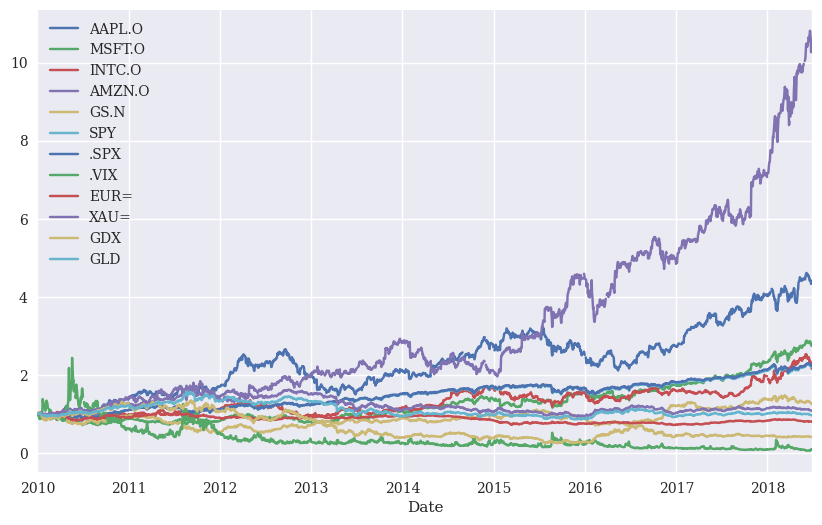

In [41]:
rets.cumsum().apply(np.exp).plot(figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Cumulative Returns and Normalization</b>

* After deriving the log returns, we perform a cumulative summation and exponentiation to visualize the <b>growth of a hypothetical \$1 investment</b> across all assets:

* <b>Mathematical Transformation:</b>By applying 'rets.cumsum().apply(np.exp)', we convert log returns back into a cumulative performance index.This process 'normalizes' the data, starting every asset at a common base of 1.0 in 2010.

* <b>Comparitive Performance:</b> The line chart clearly illustrates the massive outperformance of certain growth stocks. For instance, <b>AMZN.O</b> scales significantly higher than the rest of the portfolio, finishing near the 10.0 mark (a 10x return).




In [42]:
df.resample('1w', label='right').last().head()

C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\1009130987.py:1: FutureWarning: 'w' is deprecated and will be removed in a future version, please use 'W' instead.
  df.resample('1w', label='right').last().head()


,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.4323,1096.35,NaN,NaN
2010-01-10,30.282827,30.66,20.83,133.52,174.31,114.57,1144.98,18.13,1.4412,1136.10,49.84,111.37
2010-01-17,29.418542,30.86,20.80,127.14,165.21,113.64,1136.03,17.91,1.4382,1129.90,47.42,110.86
2010-01-24,28.249972,28.96,19.91,121.43,154.12,109.21,1091.76,27.31,1.4137,1092.60,43.79,107.17
2010-01-31,27.437544,28.18,19.40,125.41,148.72,107.39,1073.87,24.62,1.3862,1081.05,40.72,105.96


In [43]:
df.resample('1m', label='right').last().head()

C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\1851145334.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('1m', label='right').last().head()


,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,SPY,.SPX,.VIX,EUR=,XAU=,GDX,GLD
Date,,,,,,,,,,,,
2010-01-31,27.437544,28.1800,19.40,125.41,148.72,107.3900,1073.87,24.62,1.3862,1081.05,40.72,105.960
2010-02-28,29.231399,28.6700,20.53,118.40,156.35,110.7400,1104.49,19.50,1.3625,1116.10,43.89,109.430
2010-03-31,33.571395,29.2875,22.29,135.77,170.63,117.0000,1169.43,17.59,1.3510,1112.80,44.41,108.950
2010-04-30,37.298534,30.5350,22.84,137.10,145.20,118.8125,1186.69,22.05,1.3295,1178.25,50.51,115.360
2010-05-31,36.697106,25.8000,21.42,125.46,144.26,109.3690,1089.41,32.07,1.2305,1215.71,49.86,118.881


<span style='font-size:17px'><b>Data Resampling and Time-Series Frequency</b>

* To analyze long-term trends and reduce high-frequency noise, we use <b>resampling</b> to change the granularity of our time-series data. 

* <b>Weekly Resampling ('1w'):</b> We aggregate the daily data to capture the 'last()' price of each week.

* <b>Monthly Resampling ('1m'):</b> By taking the last price of each month, we can observe long-term institutional trends and more easily calculate monthly rolling returns.



C:\Users\wyatt\AppData\Local\Temp\ipykernel_3136\3898882857.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  rets.cumsum().apply(np.exp). resample('1m', label='right').last().plot(figsize=(10,6))


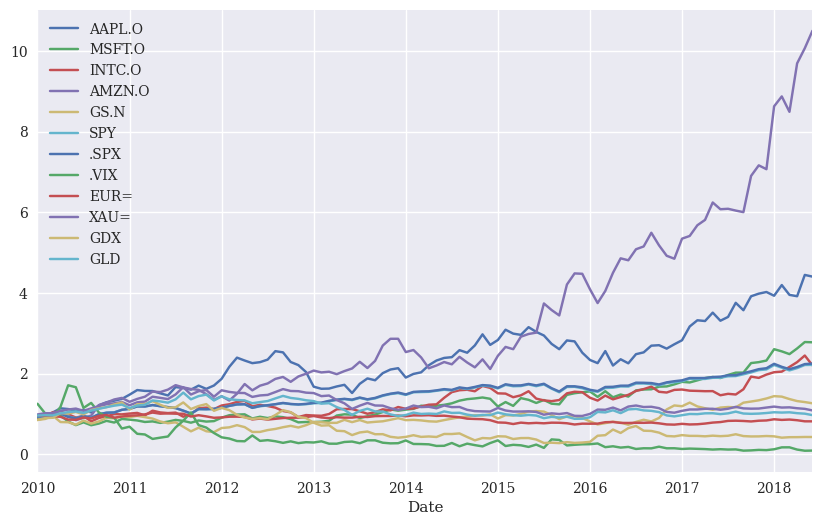

In [44]:
rets.cumsum().apply(np.exp). resample('1m', label='right').last().plot(figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Long-Term Performance and Trend Analysis</b>

* <b>Monthly Resampling:</b> By taking the 'last()' price of each month, we can see the broader trajectory of the portfolio.
* <b>Normalized Growth Visualization:</b> The final plot displays the cumulative growth of each asset, resampled monthly. This highlights the dramatic divergence in performance over the 8-year period.

sym = 'AAPL.O'

In [47]:
df = pd.DataFrame(df[sym]).dropna()

In [49]:
df.tail()

,AAPL.O
Date,
2018-06-25,182.17
2018-06-26,184.43
2018-06-27,184.16
2018-06-28,185.50
2018-06-29,185.11


<span style='font-size:17px'><b>Isolating a Single Instrument for Analysis</b>

* <b>Variable Selection:</b> We set 'sym = 'AAPL.O'' as our target ticker.
* <b>Data Cleaning:</b> A new DataFrame is created containing only the Apple price data, and we apply '.dropna()' to ensure a continuous time series for the calculation of returns.

In [50]:
window = 20

In [53]:
df['min'] = df[sym].rolling(window=window).min()

In [54]:
df['mean'] = df[sym].rolling(window=window).mean()

In [55]:
df['std'] = df[sym].rolling(window=window).std()

In [56]:
df['median'] = df[sym].rolling(window=window).median()

In [57]:
df['max'] = df[sym].rolling(window=window).max()

In [59]:
df['ewma'] = df[sym].ewm(halflife=0.5, min_periods=window).mean()

In [60]:
df.dropna().head()

,AAPL.O,min,mean,std,median,max,ewma
Date,,,,,,,
2010-02-01,27.818544,27.437544,29.580892,0.933650,29.821542,30.719969,27.805432
2010-02-02,27.979972,27.437544,29.451249,0.968048,29.711113,30.719969,27.936337
2010-02-03,28.461400,27.437544,29.343035,0.950665,29.685970,30.719969,28.330134
2010-02-04,27.435687,27.435687,29.207892,1.021129,29.547113,30.719969,27.659299
2010-02-05,27.922829,27.435687,29.099892,1.037811,29.419256,30.719969,27.856947


<span style='font-size:17px'><b>Rolling Statistical Analysis (Technical Indicators)</b>

* <b>Rolling Boundaries:</b> The 'min' and 'max' columns establish a 20-day 'price envelope,' showing the highet and lowest points the stock reached within that timeframe.
* <b>Volatility Tracking:</b> The 'std' provides a moving measure of risk, showing how much the price fluctuates day-to-day over the last 20 sessions.
* <b>Exponential Smoothing (EWMA):</b> The 'ewma' column applies an exponentially weighted moving average with a short half-life (0.5), making it more responsive to the most recent price changes than a simple moving average.

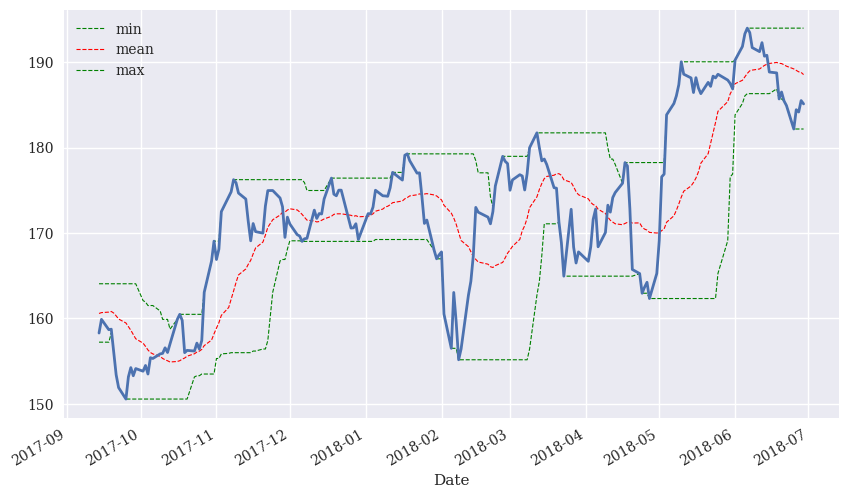

In [63]:
ax = df[['min', 'mean', 'max']].iloc[-200:].plot(
    figsize=(10,6), style=['g--', 'r--', 'g--'], lw=0.8)
df[sym].iloc[-200:].plot(ax=ax, lw=2.0)
plt.show()

<span style='font-size:17px'><b>Rolling Technical Indicators and Price Envelopes</b>

* <b>Visualizing the 'Price Channel':</b> The final plot displays the last 200 days of Apple's price action filtered through these metrics. When the solid blue price lines touches the green dashed boundaries, it indicates a period of local exhaustion or breakout from its recent trading range.
  

In [64]:
df['SMA1'] = df[sym].rolling(window=42).mean()

In [65]:
df['SMA2'] = df[sym].rolling(window=252).mean()

In [66]:
df[[sym, 'SMA1', 'SMA2']].tail()

,AAPL.O,SMA1,SMA2
Date,,,
2018-06-25,182.17,185.606190,168.265556
2018-06-26,184.43,186.087381,168.418770
2018-06-27,184.16,186.607381,168.579206
2018-06-28,185.50,187.089286,168.736627
2018-06-29,185.11,187.470476,168.901032


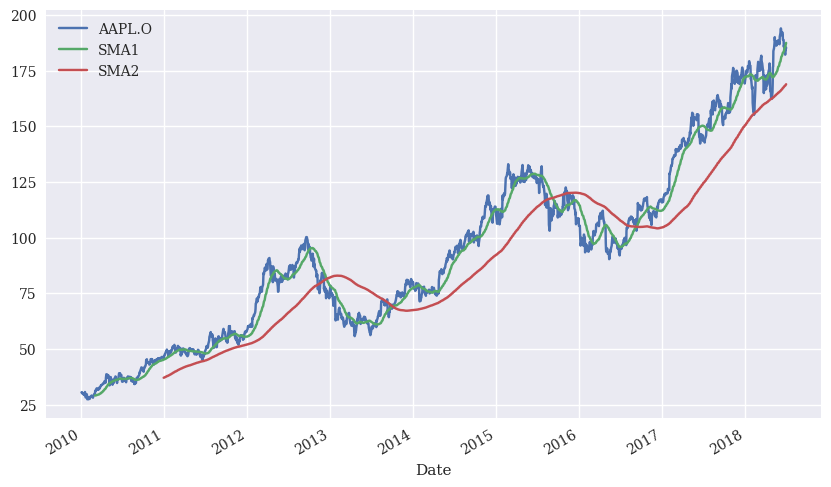

In [69]:
df[[sym, 'SMA1', 'SMA2']].plot(figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Trend Analysis using Simple Moving Averages (SMA)</b>

* <b>Short-Term Momentum (SMA1):</b> A 42-day moving average that tracks more recent price shifts.
* <b>Long-Term Trend (SMA2):</b> A 252-day moving average, representing approximately one trading year, used to smooth out significant price volatility.
* <b>Visualization:</b> The resulting plot shows the raw price (blue) overlaid with the two SMAs. The divergence beteen the price and the SMA2 (red line) highlights sustained periods of bullish momentum throughout 2017 and 2018.

In [71]:
df.dropna(inplace=True)

In [72]:
df['positions'] = np.where(df['SMA1'] > df['SMA2'],
                           1, 
                           -1)

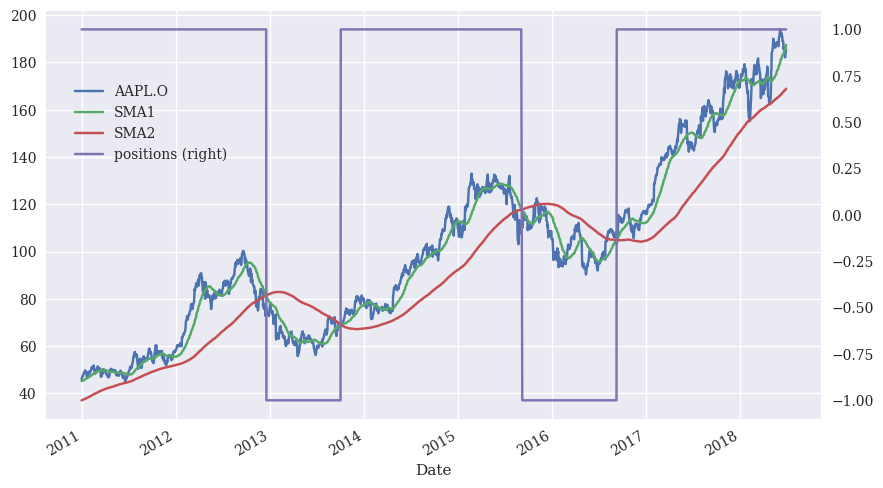

In [76]:
ax = df[[sym, 'SMA1', 'SMA2', 'positions']].plot(figsize=(10,6),
                                                 secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((0.25, 0.85))
plt.show()

<span style='font-size:17px'><b>Implementing an SMA Crossover Strategy</b>

* <b>Strategy Logic:</b> We use 'np.where' to define a binary position. When the short-term trend (SMA1) is above the long-term trend (SMA2), the strategy enters a 'Long' position (+1). Conversely, it enters a 'Short' position (-1) when the short-term trend falls below the the long-term average.
* <b>Position Visualization:</b> The purple step-line on the secondary y-axis represents these shifts. Tou can see the strategy capture the major uptrend in APPL.O starting in later 2016, maintaining a consistent 'Long' position as the stock climbed toward 200.
* <b>Signal Lag:</b> Note how the 'Short' positions (e.g., during 2013 and 2016) often occur after a significant price drop, illustrating the lagging nature of moving average crossovers.

In [80]:
url = 'https://raw.githubusercontent.com/yhilpisch/py4fi2nd/master/source/tr_eikon_eod_data.csv'
raw = pd.read_csv(url, index_col=0, parse_dates=True)

In [81]:
df = raw[['.SPX', '.VIX']].dropna()

In [82]:
df.tail()

,.SPX,.VIX
Date,,
2018-06-25,2717.07,17.33
2018-06-26,2723.06,15.92
2018-06-27,2699.63,17.91
2018-06-28,2716.31,16.85
2018-06-29,2718.37,16.09


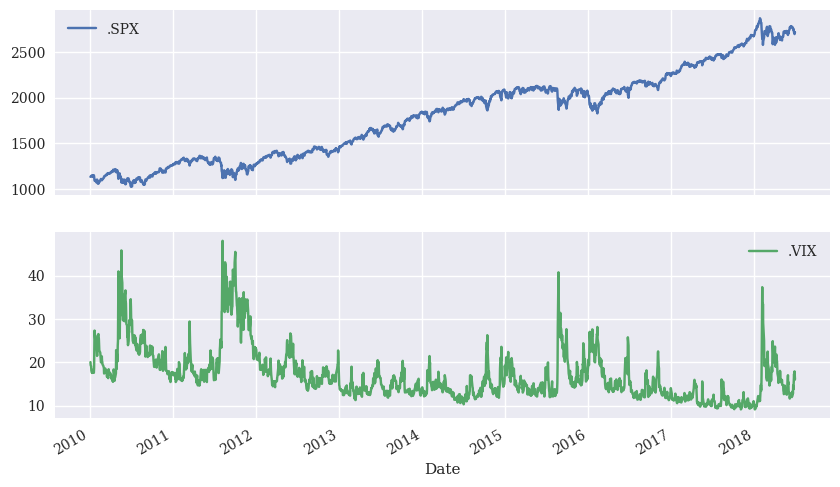

In [85]:
df.plot(subplots=True, figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Comparitive Analysis: Trends vs. Volatility</b>

* <b>S&P 500 (.SPX):</b> The top panel displays a clear long-term bullish trend, with the index rising from roughly 1,000 to over 2,700 by mid-2018.
* <b>VIX Volatility Index (.VIX):</b> The bottom panel captures market sentiment and 'fear.' Unlike the price index, the VIX is mean-reverting, characterized by sharp vertical spikes during periods of market stress (e.g., 2011 and early 2018) followed by long periods of relative calm.
* <b>Inverse Correlation:</b> Visually, local peaks in the VIX often correspond directly with sharp, temporary pullbacks in the .SPX, highlighting the 'tail risk' events that this notebook aims to analyze further.
  

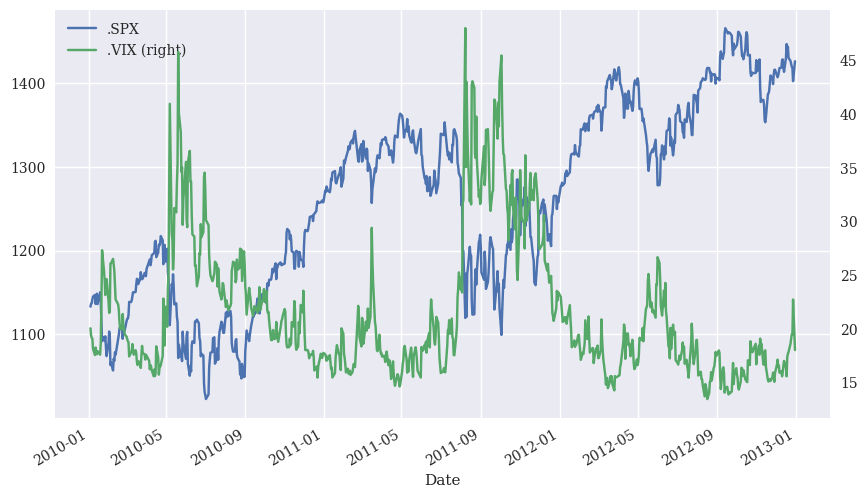

In [94]:
df.loc[:'2012-12-31'].plot(secondary_y='.VIX', figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Overlapped Market and Volatility (2010-2012)</b>

* <b>Overlapped Dynamics:</b> By placing both series on the same plot, the relationship becomes visually striking-sharp spikes in the '.VIX' (green line) align perfectly with deep troughs or 'tail events' in the '.SPX' (blue line).
* <b>Secondard Axis:</b> To account for the different scales (index points vs. percentage points), the '.VIX' is plotted on a secondary y-axis.
* <b>Time Filtering:</b> The view is restricted to the 2010-2012 window using '.loc', allowing for a more granular look at the marekt volatility during those specific years.

In [97]:
rets = np.log(df/ df.shift(1))

In [98]:
rets.head()

,.SPX,.VIX
Date,,
2010-01-04,NaN,NaN
2010-01-05,0.003111,-0.035038
2010-01-06,0.000545,-0.009868
2010-01-07,0.003993,-0.005233
2010-01-08,0.002878,-0.050024


In [100]:
rets.dropna(inplace=True)

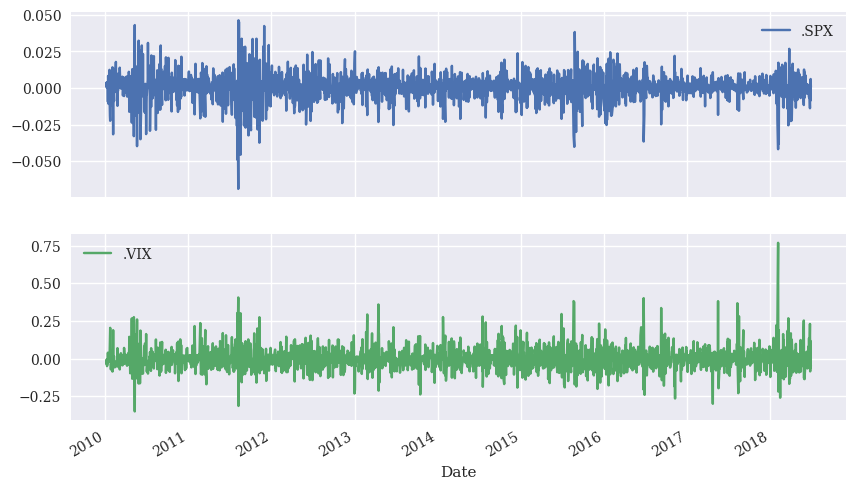

In [103]:
rets.plot(subplots=True, figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Visualizing Daily Log Returns: .SPX vs. .VIX</b>

* <b>Return Distributions:</b> The subplots reveal the 'heartbeat' of the market. While the .SPX returns typically oscillate between +/- 2.5%, the .VIX returns are significantly more volatile, frequently spiking above 25% or even 50% in a single day.
* <b>Volatility Clustering:</b> The plots clearly show periods of 'volatility clustering', where large returns (the tails) are followed by more large returns, particularly visible during the market stress of 2011 and early 2018.

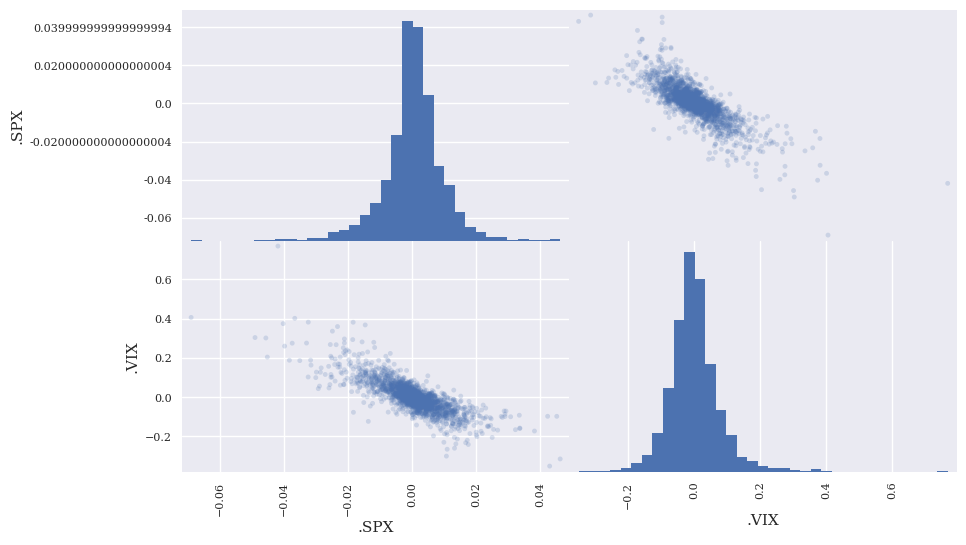

In [107]:
pd.plotting.scatter_matrix(rets,
                           alpha=0.2, 
                           diagonal='hist',
                           hist_kwds={'bins': 35},
                           figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Analyzing Correlation: .SPX vs. .VIX</b>

* <b>Negative Correlation:</b> The scatter plots reveal a strong negative linear relationship between the .SPX and the .VIX. When the S&P500 produces negative log returns, the VIX typically sees a significant spike, confirming its role asthe 'fear index.'
* <b>Log Return Histograms:</b> The diagonal histograms show the frequency distribution of daily returns. The .SPX displays a taller, narrower peak (lower volatility), while the .VIX histogram is broader with a heavier right tail, indicating frequent large positive jumps.

In [109]:
reg = np.polyfit(rets['.SPX'], rets['.VIX'],deg=1)

In [111]:
ax = rets.plot(kind='scatter', x= '.SPX', y='.VIX',figsize=(10,6))

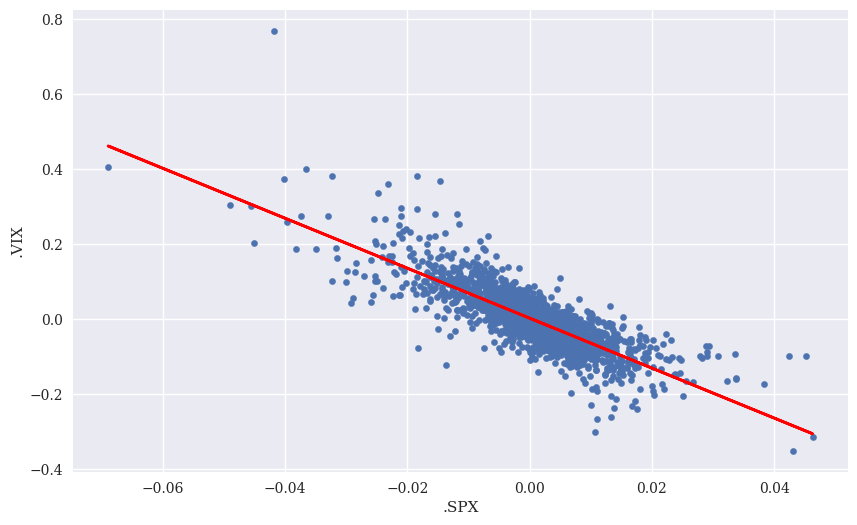

In [112]:
ax.plot(rets['.SPX'], np.polyval(reg, rets['.SPX']), 'r', lw=2)
plt.show()

<span style='font-size:17px'><b>Linear Regression: .SPX vs. .VIX</b>

* <b>Negative Correlation:</b> The scatter plot and the red regression line illustrate a strong negative correlation between the two indices. When the .SPX has negative returns, the .VIX typically sees a significant positive jump.
* <b>Hedging Characteristics:</b> This inverse relationship highlights why the VIX is often used as a hedging instrument; it tends to gain value precisely when the equity market is experiencing a downturn.

In [113]:
rets.corr()

,.SPX,.VIX
.SPX,1.000000,-0.804382
.VIX,-0.804382,1.000000


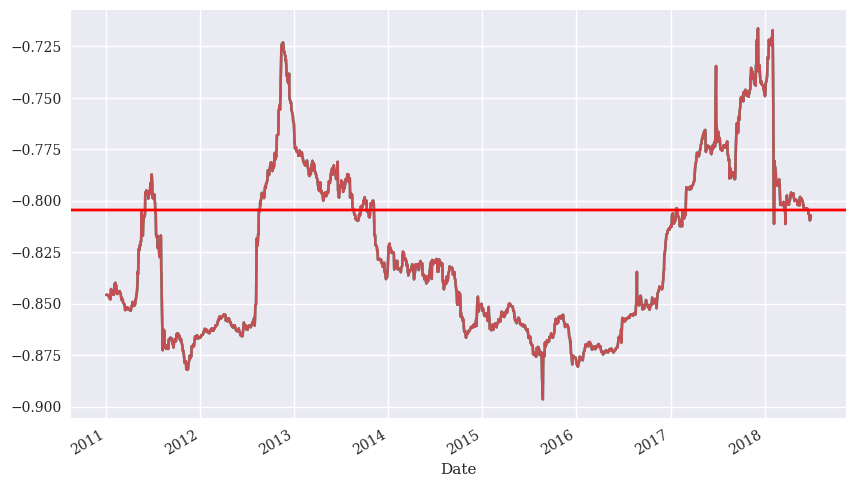

In [116]:
ax = rets['.SPX'].rolling(window=252).corr(
    rets['.VIX']).plot(figsize=(10,6))
ax.axhline(rets.corr().iloc[0, 1], c='r')
plt.show()

<span style='font-size:17px'><b>Rolling Correlation: .SPX vs. .VIX</b>

* <b>Persistent Inverse Relationship:</b> The plot shows the 252-day rolling correlation between the .SPX and .VIX. The correlation is consistently and significantly negative, rarely rising above -0.70, which reinforces the VIX's status as a reliable equity hedge.
* <b>Dynamic Correlation:</b> While the relationship is always negative, it is not static. The 'spikes' in the correlation line (moving toward zero) often coincide with major market shifts or regime changes, though the overall mean (the red line) remains near -0.80.

In [127]:
%%time
url = 'https://raw.githubusercontent.com/yhilpisch/py4fi2nd/master/source/fxcm_eur_usd_tick_data.csv'
tick= pd.read_csv(url, index_col=0, parse_dates=True)

CPU times: total: 1.62 s
Wall time: 2.64 s


In [128]:
tick.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 461357 entries, 2018-06-29 00:00:00.082000 to 2018-06-29 20:59:00.607000
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Bid     461357 non-null  float64
 1   Ask     461357 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


In [129]:
tick['Mid']= tick.mean(axis=1)

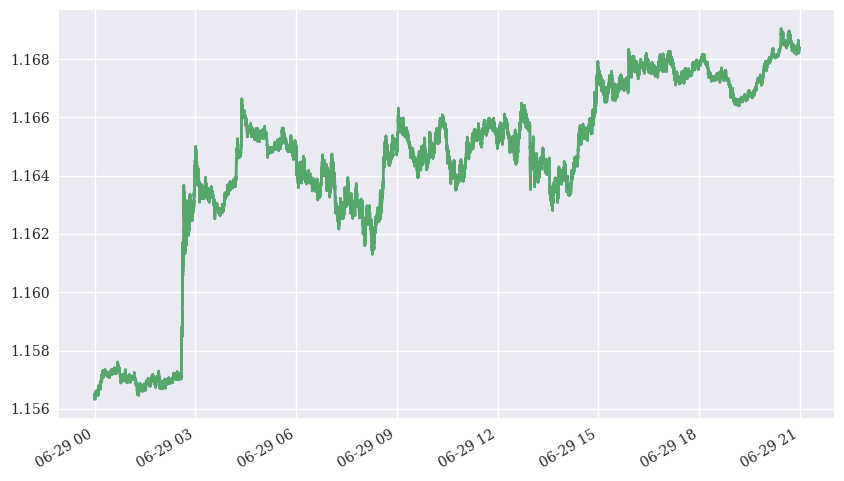

In [131]:
tick['Mid'].plot(figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>High-Frequency Tick Data: EUR/USD</b>

* <b>Intraday Dynamics:</b> The plot visualizes the 'Mid' price for the EUR/USD currency pair over a single trading day (2018-06-29). By averaging the Bid and Ask prices, we capture the continuous movement of the market at the millisecond level.
* <b>Microstructure Analysis:</b> Unlike daily or hourly bars, tick data reveals the raw volatility and liquidity of the FX markets. This granular view is essential for developing high-frequency trading algorithms and analyzing market impact.

In [132]:
tick_resam = tick.resample(rule='5min', label='right').last()

In [135]:
tick_resam.head()

,Bid,Ask,Mid
2018-06-29 00:05:00,1.15649,1.15651,1.156500
2018-06-29 00:10:00,1.15671,1.15672,1.156715
2018-06-29 00:15:00,1.15725,1.15727,1.157260
2018-06-29 00:20:00,1.15720,1.15722,1.157210
2018-06-29 00:25:00,1.15711,1.15712,1.157115


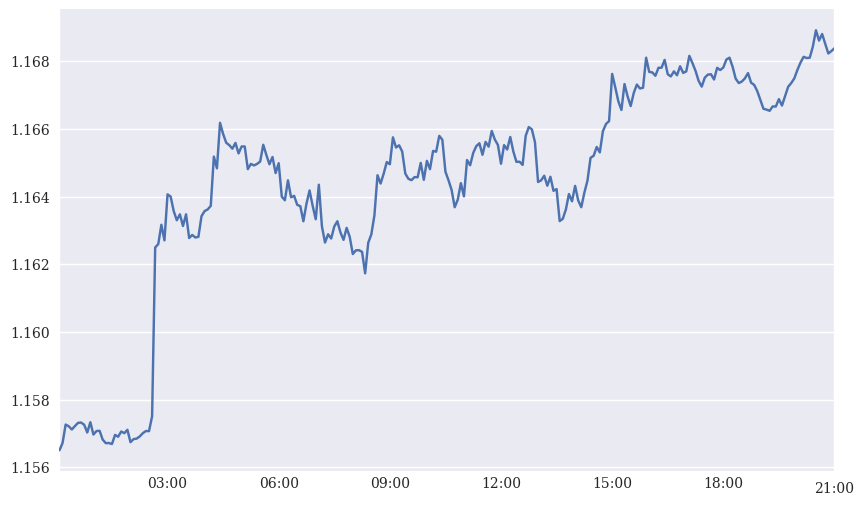

In [136]:
tick_resam['Mid'].plot(figsize=(10,6))
plt.show()

<span style='font-size:17px'><b>Resampled Efficiency: 5-Minute EUR/USD Mid-price</b>

* <b>Data Compression:</b> The plot illustrates the EUR/USD 'Mid' price after resampling the raw tick data into 5-minute intervals. This process significantly reduces the noise and computational overhead while preserving the primary intraday price trends.
* <b>Signal Smoothing:</b> By using the '.resample('5min').last()' method, we move from the high-frequency 'micro' view to a structured time series. This is a critical step for aligning disparate data sources or preparing features for technical analysis indicators.